---
title: "Социология парламентарни избори 2026"
description: "Този бележник анализира разликите електоралните нагласи отчетени от различните социологически агенции и реалните изборни резултати."
author: "Григор Димитров"
categories: "sociology"
date: "2026-04-23"
toc: true
format:
  html:
    code-fold: true
    code-summary: "Show the code"
---

In [2]:
import pandas as pd
import requests
import json
import numpy as np

# 1. Use the RAW URL from your gist (Note the 'gist.githubusercontent' domain)
url = "https://gist.githubusercontent.com/gregordimi/e0d3fe30e4f898c84ad25c38b39f6e44/raw/311a84fb7ce48c8bc47d61b359405d602b2aabd6/results2026.json"

# 2. Fetch the data using requests
response = requests.get(url)
data = response.json()

# 3. Your existing processing logic
survey_list = []
for s in data['surveys']:
    entry = s['results'].copy()
    entry['Agency'] = s['agency']
    entry['Date'] = s['date_iso']
    entry['Label'] = f"{s['agency']} ({s['date_label']})"

    # Store metadata separately if you want to use it for the cards
    entry['metadata'] = s.get('metadata', {})

    survey_list.append(entry)

df = pd.DataFrame(survey_list).set_index('Label')
actual = pd.Series(data['actual'], name='РЕАЛНИ РЕЗУЛТАТИ')

print(f"Данните за {len(df)} проучвания са заредени успешно")
print(url)
# df.head()

Данните за 20 проучвания са заредени успешно
https://gist.githubusercontent.com/gregordimi/e0d3fe30e4f898c84ad25c38b39f6e44/raw/311a84fb7ce48c8bc47d61b359405d602b2aabd6/results2026.json


# Паспорти на публичните социологически изследвания за парламентарни избори 2026

Техническите данни за изследванията


In [3]:
from IPython.display import HTML, display

def render_facet_row(data):
    all_cards = ""

    for s in data['surveys']:
        m = s.get('metadata', {})
        o = m.get('other_metadata', {})

        # Strip-down card template
        card_html = f"""
        <div style="flex: 1; min-width: 220px; max-width: 300px; border: 1px solid #888;
                    border-radius: 8px; padding: 12px; background: #fff; font-family: sans-serif;
                    box-shadow: 2px 2px 5px rgba(0,0,0,0.05); font-size: 12px;">
            <div style="color: #111; font-weight: bold; border-bottom: 1px solid #eee;
                        margin-bottom: 8px; padding-bottom: 4px; font-size: 13px;">
                {s['agency']} ({s['date_label']})
            </div>
            <div style="color: #777; margin-bottom: 4px;"><b>Период:</b> {m.get('date', 'N/A')}</div>
            <div style="color: #777; margin-bottom: 4px;"><b>Извадка:</b> {m.get('sample_size', 'N/A')}</div>
            <div style="color: #777; margin-bottom: 4px;"><b>Метод:</b> {m.get('methodology', 'N/A')}</div>
            <div style="color: #777; font-size: 11px; margin-top: 8px; font-style: italic;">
                Грешка: {o.get('margin_of_error', 'N/A')}
            </div>
        </div>
        """
        all_cards += card_html

    # Display wrapper with Flexbox
    display(HTML(f"""
    <div style="display: flex; flex-wrap: wrap; gap: 15px; background: #f4f4f4; padding: 20px; border-radius: 12px;">
        {all_cards}
    </div>
    """))

# Execute to render all 19 cards
render_facet_row(data)

## Данните
Тази графика показва всички публикувани данни на горните проучвания които са анализирани в това мета изследване.

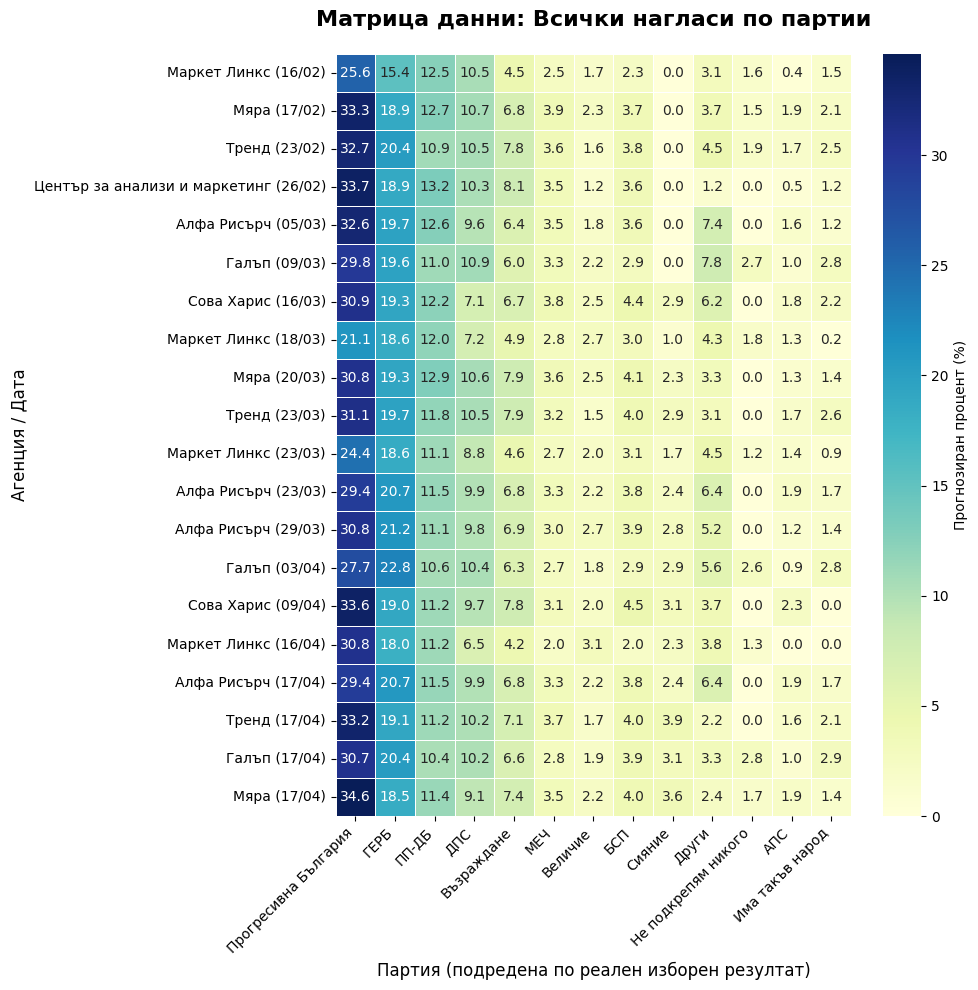

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Филтрираме колоните (същата логика)
cols = [c for c in df.columns if c not in ['Agency', 'Date', 'metadata', 'Не съм решил']]

# 2. Сортираме партиите по техния реален резултат
sorted_parties = actual[cols].sort_values(ascending=False).index

# 3. Вземаме СУРОВИТЕ ДАННИ (df вместо residuals)
raw_data_matrix = df[sorted_parties]

# 4. Визуализация
plt.figure(figsize=(10, 10))

# Използваме 'YlGnBu' (Yellow-Green-Blue), защото това са абсолютни стойности (0-100),
# а не отклонения около нулата.
sns.heatmap(raw_data_matrix,
            annot=True,
            fmt='.1f',
            cmap='YlGnBu',
            linewidths=.5,
            cbar_kws={'label': 'Прогнозиран процент (%)'})

plt.title('Матрица данни: Всички нагласи по партии', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Партия (подредена по реален изборен резултат)', fontsize=12)
plt.ylabel('Агенция / Дата', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

## Отклоненията (Residual Heatmap)
Тази графика показва отклоненията на публукуваните електорални нагласи в различните проучвания от реалния изборен резултат

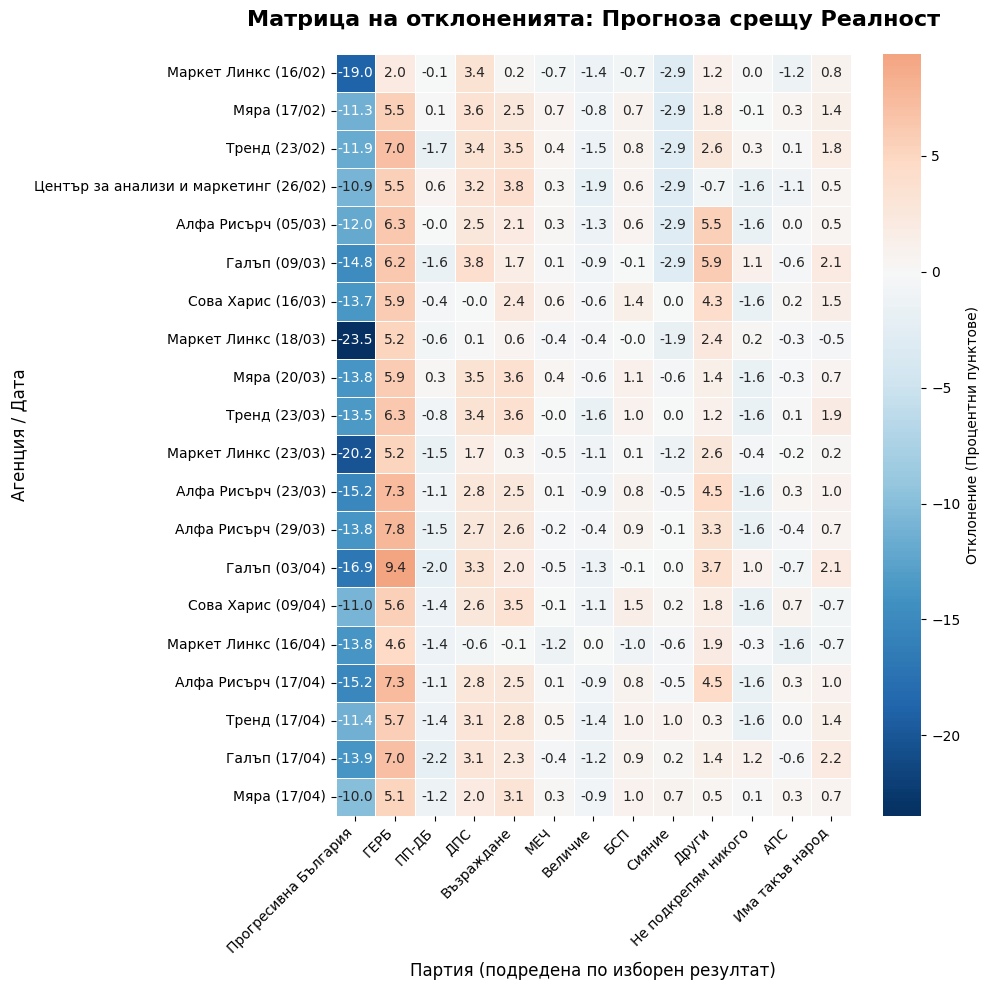

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Филтрираме само колоните с партии (изключваме метаданните и служебните категории)
cols = [c for c in df.columns if c not in ['Agency', 'Date', 'metadata', 'Не съм решил']]

# 2. Изчисляваме остатъците (Прогноза минус Реалност)
# Резултат > 0: Партията е била надценена (Survey > Actual)
# Резултат < 0: Партията е била подценена (Survey < Actual)
residuals = df[cols].sub(actual[cols], axis=1)

# 3. Сортираме партиите по техния реален изборен резултат за по-добра четимост
sorted_parties = actual[cols].sort_values(ascending=False).index

# 4. Визуализация на Heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(residuals[sorted_parties],
            annot=True,
            fmt='.1f',
            cmap='RdBu_r',
            center=0,
            linewidths=.5,
            cbar_kws={'label': 'Отклонение (Процентни пунктове)'})

plt.title('Матрица на отклоненията: Прогноза срещу Реалност', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Партия (подредена по изборен резултат)', fontsize=12)
plt.ylabel('Агенция / Дата', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

## Средна Абсолютна Грешка (MAE)

Средна абсолютна грешка. Измерва средната големина на отклоненията в набор от прогнози, без да отчита тяхната посока (дали е надценено или подценено). Всички грешки се третират с еднаква тежест.

Колкото по-ниска е стойността, толкова по-точни са били данните спрямо официално регистрирания вот в деня на изборите.

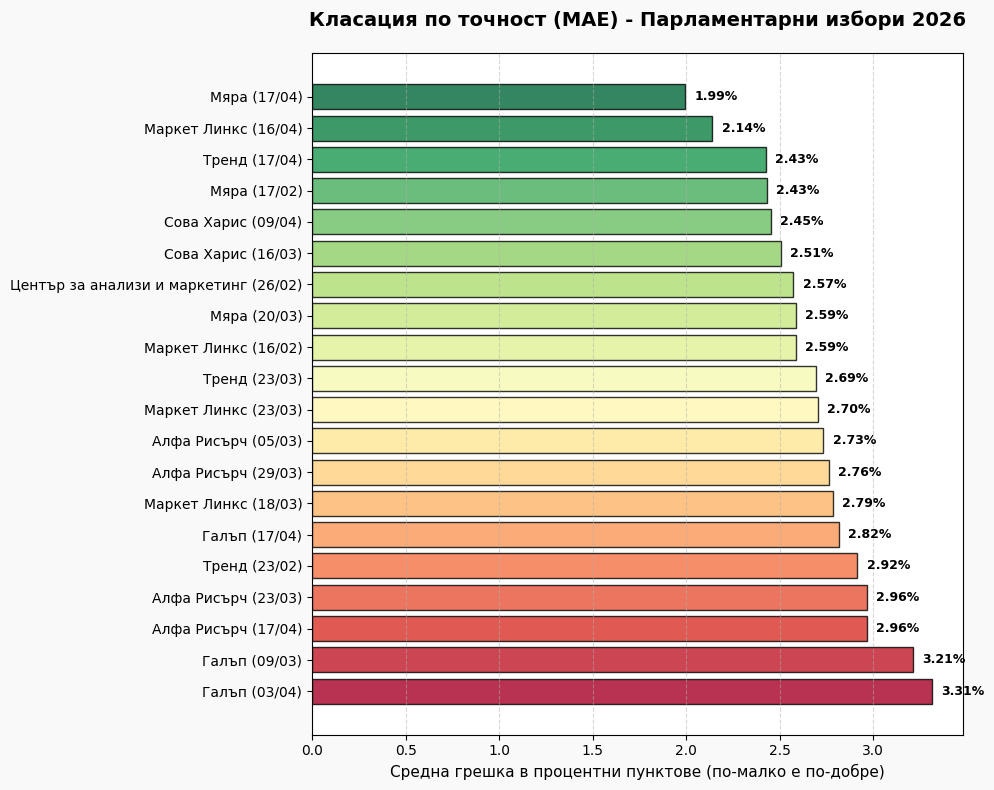

🏆 НАЙ-ТОЧНА ПРОГНОЗА: Мяра (17/04) (Грешка: 1.99%)


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Избор на партиите за сравнение (премахваме метаданните и служебните категории)
cols = [c for c in df.columns if c not in ['Agency', 'Date', 'metadata', 'Не съм решил']]

# 2. Изчисляване на MAE за всеки ред спрямо 'actual'
# Използваме .dropna(), за да сме сигурни, че сравняваме само съществуващи данни
mae = df[cols].apply(lambda x: np.mean(np.abs(x - actual[cols])), axis=1).sort_values()

# 3. Визуализация
plt.figure(figsize=(10, 8), facecolor='#f9f9f9')
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(mae)))

# Хоризонтален бар
bars = plt.barh(mae.index, mae.values, color=colors, edgecolor='black', alpha=0.8)

# Добавяне на стойностите върху баровете
for bar in bars:
    plt.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.2f}%', va='center', fontsize=9, fontweight='bold')

plt.title('Класация по точност (MAE) - Парламентарни избори 2026', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Средна грешка в процентни пунктове (по-малко е по-добре)', fontsize=11)
plt.gca().invert_yaxis()  # Най-точните най-отгоре
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# Бонус: Кратка присъда
winner = mae.index[0]
print(f"🏆 НАЙ-ТОЧНА ПРОГНОЗА: {winner} (Грешка: {mae.iloc[0]:.2f}%)")

## Средноквадратична грешка. (RMSE)

Изчислява се като корен квадратен от средната стойност на квадратите на разликите. Тъй като грешките се вдигат на квадрат преди да се усреднят, тази метрика дава много по-голяма тежест на големите отклонения.

Колкото по-ниска е стойността, толкова по-точни са били данните спрямо официално регистрирания вот в деня на изборите.

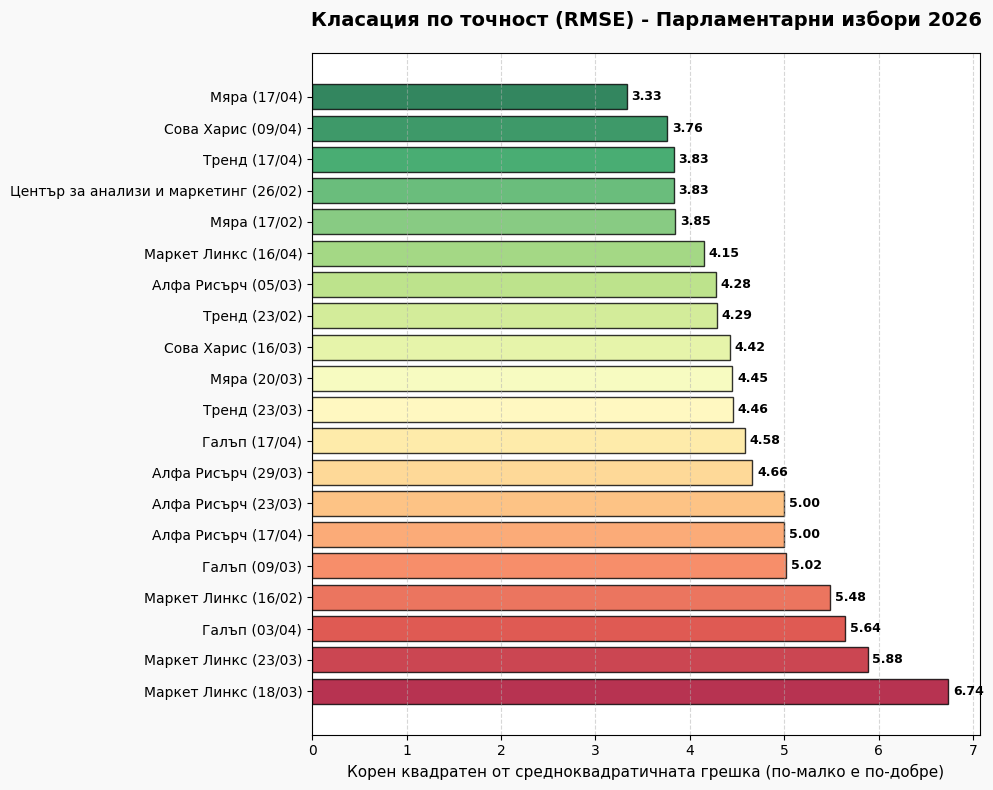

🏆 НАЙ-ТОЧНА ПРОГНОЗА (RMSE): Мяра (17/04) (Грешка: 3.33)


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Избор на партиите
cols = [c for c in df.columns if c not in ['Agency', 'Date', 'metadata', 'Не съм решил']]

# 2. Изчисляване на RMSE (Root Mean Square Error)
# RMSE = Квадратен корен от средната стойност на квадратите на разликите
rmse = df[cols].apply(lambda x: np.sqrt(np.mean((x - actual[cols])**2)), axis=1).sort_values()

# 3. Визуализация
plt.figure(figsize=(10, 8), facecolor='#f9f9f9')
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(rmse)))

bars = plt.barh(rmse.index, rmse.values, color=colors, edgecolor='black', alpha=0.8)

for bar in bars:
    plt.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.2f}', va='center', fontsize=9, fontweight='bold')

plt.title('Класация по точност (RMSE) - Парламентарни избори 2026', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Корен квадратен от средноквадратичната грешка (по-малко е по-добре)', fontsize=11)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

winner = rmse.index[0]
print(f"🏆 НАЙ-ТОЧНА ПРОГНОЗА (RMSE): {winner} (Грешка: {rmse.iloc[0]:.2f})")

### Tренд
Тук проследяваме как прогнозите за основните партии са се променяли във времето спрямо крайния резултат.

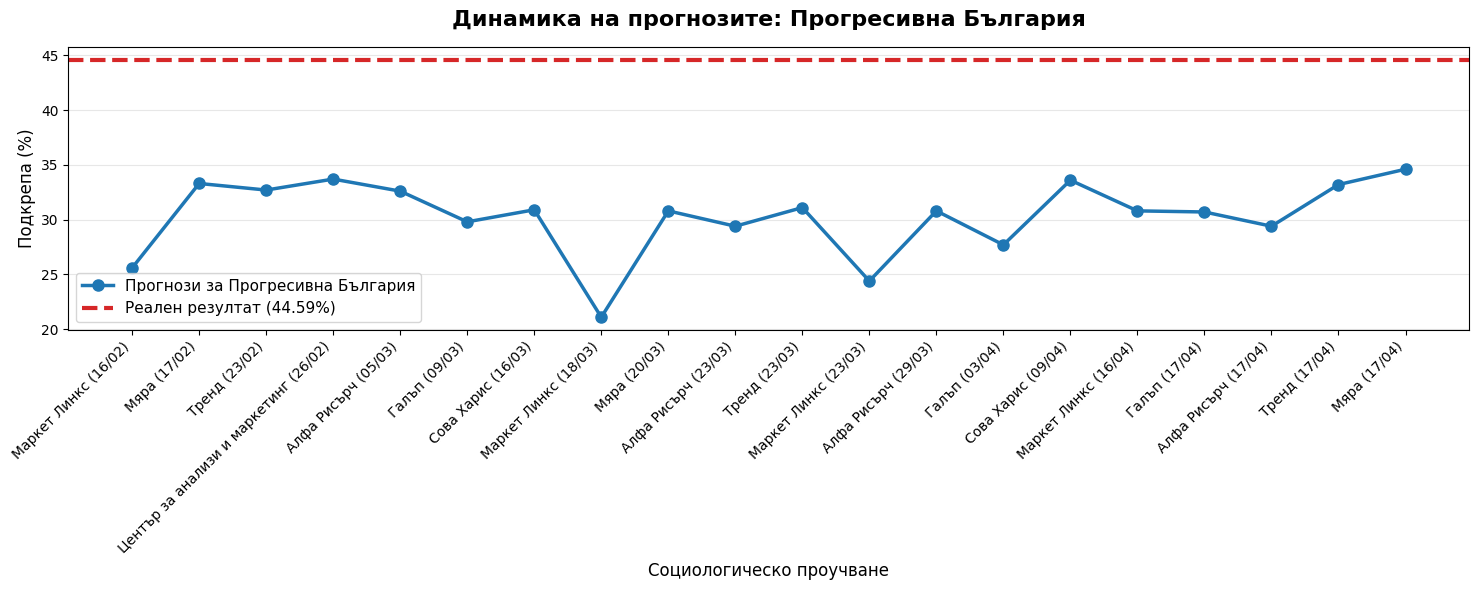

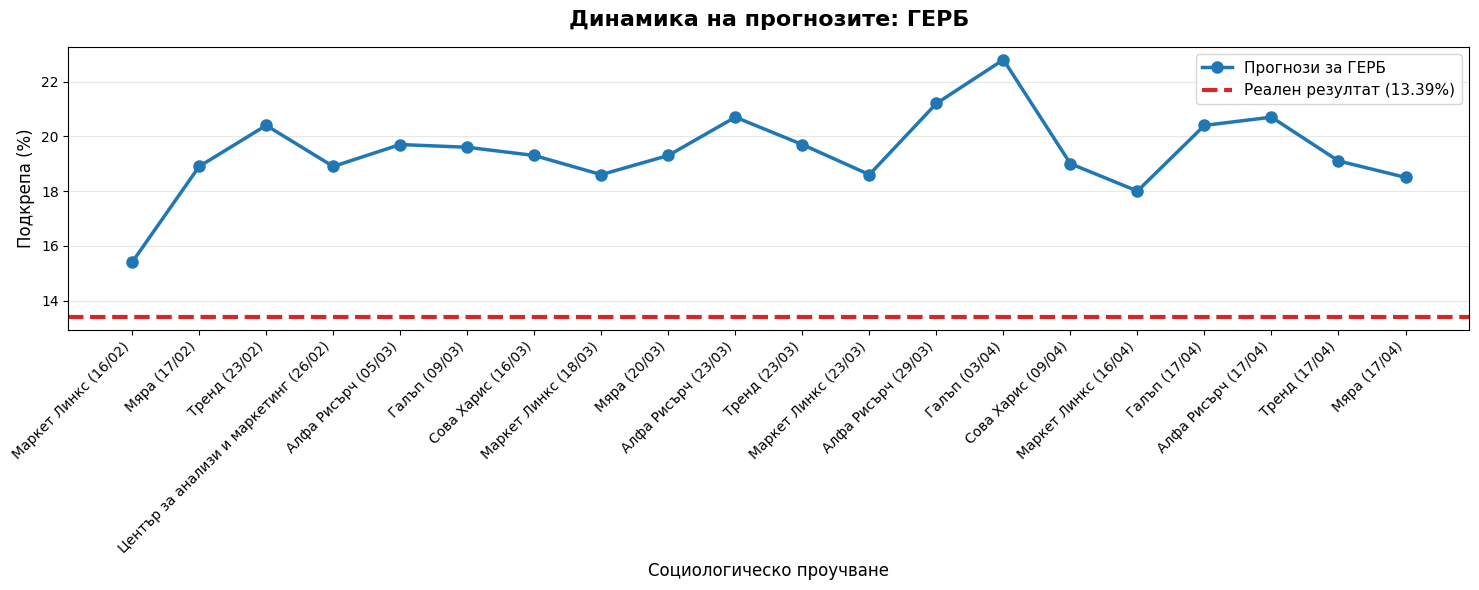

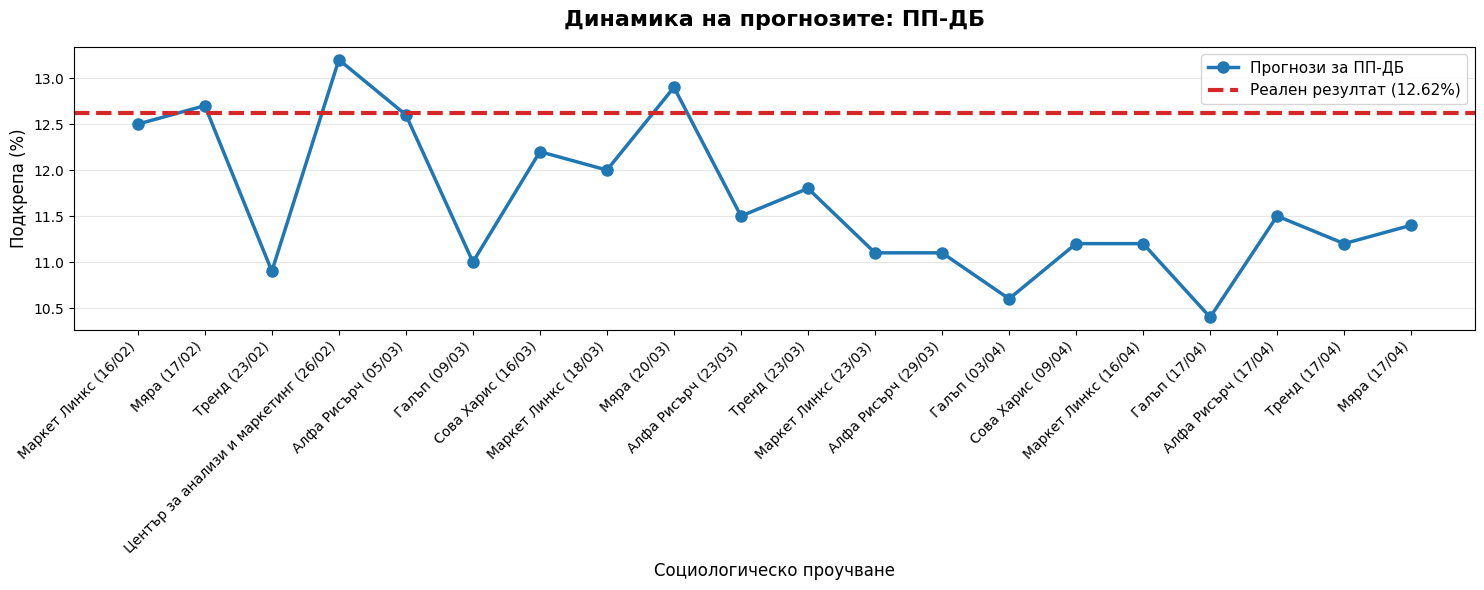

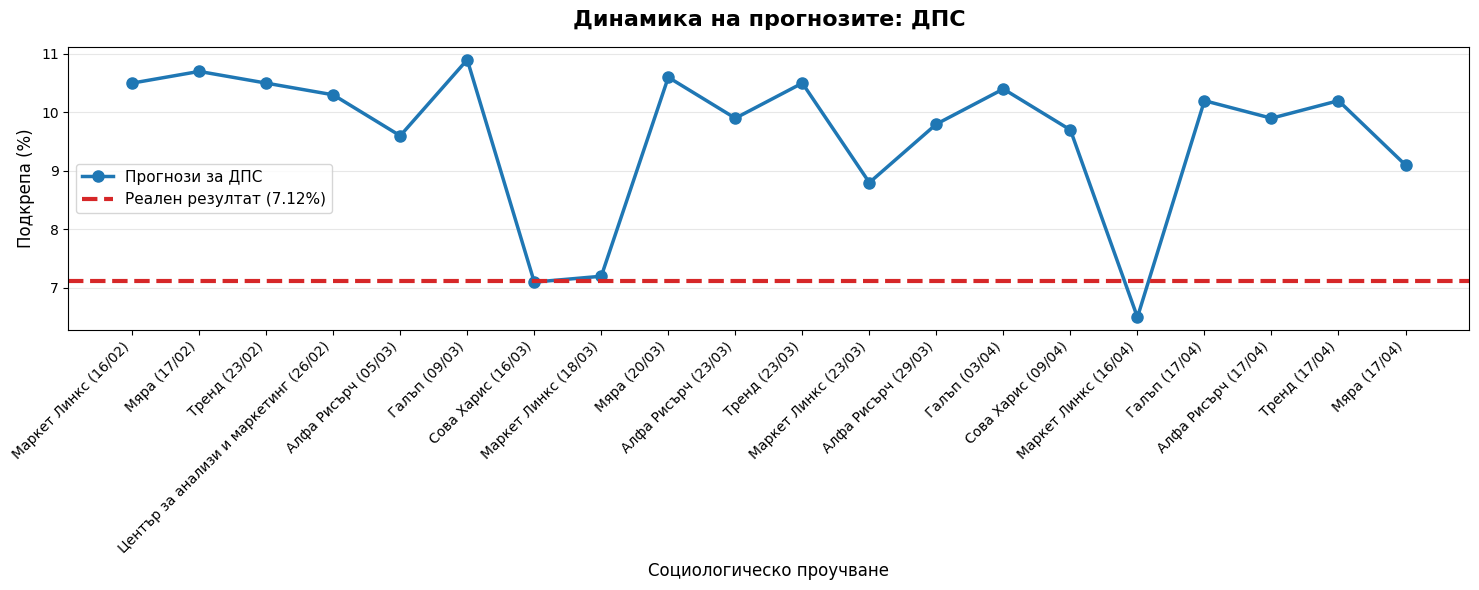

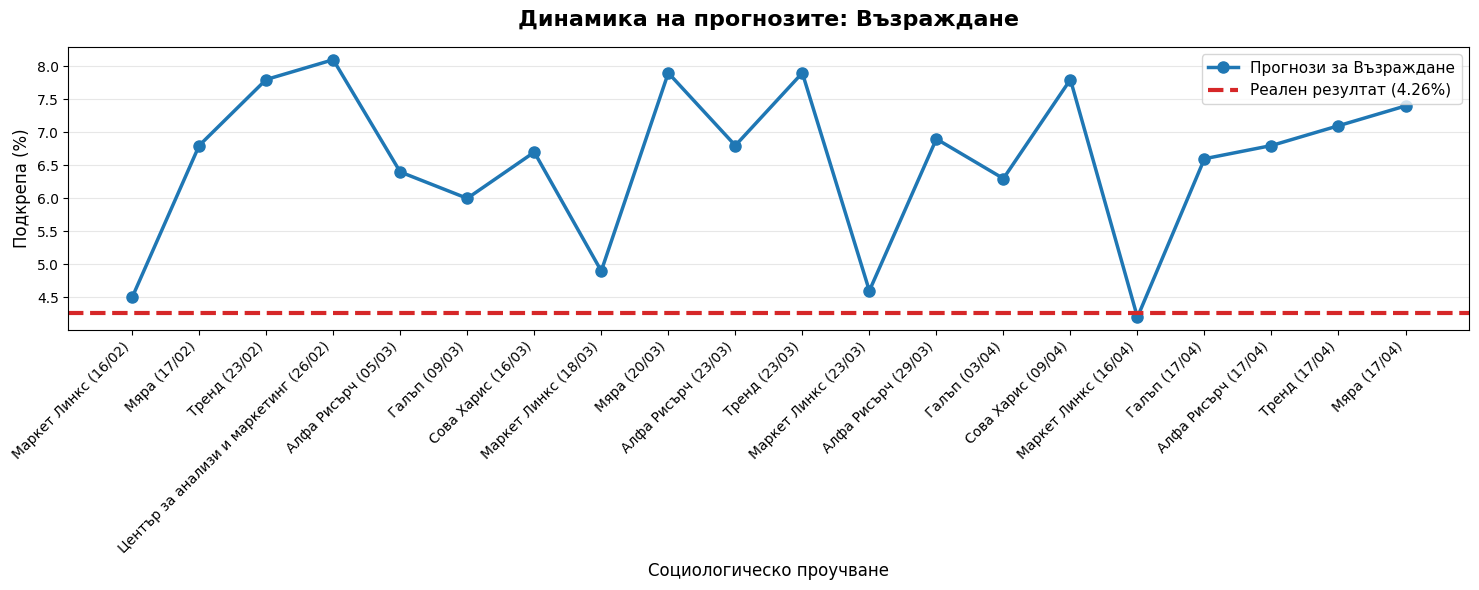

In [7]:
import matplotlib.pyplot as plt

# 1. Списък с партиите, които искаме да проследим
target_parties = ['Прогресивна България', 'ГЕРБ', 'ПП-ДБ', 'ДПС', 'Възраждане']

# 2. Сортираме данните хронологично
trend_df = df.sort_values('Date')

# 3. Цикъл за генериране на всяка графика
for party in target_parties:
    plt.figure(figsize=(15, 6))

    # Проверка дали партията съществува в данните (за избягване на грешки)
    if party in trend_df.columns:
        # Плотване на прогнозите
        plt.plot(trend_df.index, trend_df[party],
                 marker='o', color='#1f77b4', linewidth=2.5, markersize=8, label=f'Прогнози за {party}')

        # Линия за реалния резултат
        actual_val = actual[party]
        plt.axhline(y=actual_val, color='#d62728', linestyle='--',
                    linewidth=3, label=f'Реален резултат ({actual_val}%)')

        # Оформление
        plt.title(f'Динамика на прогнозите: {party}', fontsize=16, fontweight='bold', pad=15)
        plt.ylabel('Подкрепа (%)', fontsize=12)
        plt.xlabel('Социологическо проучване', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.legend(fontsize=11, loc='best')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()

        plt.show()
    else:
        print(f"Партията '{party}' не беше намерена в данните.")

### **Анализ на ефекта от методологията (Offline vs. Hybrid)**

Статистическият модел (**OLS**) изолира „чистия“ ефект на изследователския метод върху точността на прогнозите. Вместо просто да гледаме крайната грешка, ние измерваме колко точно методологията **„натежава“** върху резултата, като контролираме за фактори кога е правено проучването или колко голяма е била извадката.

Трябва да се отбележи, че в текущата извадка хибридният метод се припокрива значително с една от конкретните агенции и не може категорично да се изолира дали източникът на влияние е самата агенция, или методологията. Както при много статистически изследвания, основна препоръка е: „further research needed, need more data“.

#### **Основни изводи за коефициентите:**
* **Линеен шум (+1.06):** Използването на хибриден метод (онлайн + офлайн) автоматично вкарва малко над 1 процентен пункт допълнително отклонение в средната грешка (**MAE**) спрямо чисто офлайн проучванията.
* **Квадратна грешка (+2.82):** При квадратичната грешка (**RMSE**), наказанието за хибридния метод е близо три пъти по-високо. Това показва, че онлайн панелите са склонни да генерират „изненади“ - те не просто бъркат малко, а саклонни да генерират и по-големи пропуски.

Нека разгледаме проучване, проведено на **17 април (2 дни преди изборите)** с извадка от **1000 души**, за да видим как изборът на метод променя очакваната точност:

**Пример 1: Средно отклонение (MAE)** Ако заложите на традиционното проучване „лице в лице“, моделът предвижда средна грешка от около **2.35%**. Ако при абсолютно същите условия използвате **хибриден подход**, очакваното средно отклонение от истината скача на **3.41%** (допълнителни +1.06 пункта). 

**Пример 2: Риск от сериозно разминаване (RMSE)** Тук разликата е драстична. При офлайн проучване очакваната квадратична грешка е **4.03**. При **хибридния подход** обаче тя скача до **6.85**. Това нарастване (с над 2.8 пункта) означава, че хибридната методология е **по-несигурна**. В реалността това често се изразява в „наказване“ на конкретна партия — например, докато офлайн методът би хванал вълната за *Прогресивна България* с малка разлика, хибридната методология може да я подцени с десетки проценти, фаворизирайки погрешно статуквото.

## Относно разликата в MAE и RMSE в двете графики

Има разминаване между предходните графики и графиките на OLS модела за двата индикатора (MAE и RMSE), тъй като те са изчислени на различна база.

### Защо?
* **Знаменателят ($n$):** MAE (Средна абсолютна грешка) се пресмята, като сумата от грешките се раздели на броя на категориите ($n$).
* Когато включваме категории с традиционно малка грешка (като „Други“ или „Не подкрепям никого“), делим общата сума на по-голямо число (напр. 12). Това изкуствено намалява средната стойност (в случая до **2.4%**).
* С регресионния анализ съм филтрирал само важните политически субекти (8 партии) и сумата от грешките се дели на по-малко число, което логично повишава MAE до **3.1%**.

Налице са две различни стойности за MAE и RMSE за едно и също проучване, което може да изглежда объркващо:
1. **2.4% (в началните бар чартове):** Изчислена върху **всички категории** (вкл. „Други“, „Не подкрепям никого“ + малки партии).
2. **3.1% (в OLS модела):** Изчислена само върху **реалните парламентарно представени партии**.

---

### Защо MAE и RMSE дават различни резултати?

Разликата в поведението на двата индикатора в графиките се дължи на начина, по който те „наказват“ отклоненията:

* **MAE (Mean Absolute Error):** Това е линеен показател. Ако сгрешиш с 10% при една партия, това добавя точно 10 единици към общата сума. MAE е по-усреднен и третира всички отклонения еднакво.
* **RMSE (Root Mean Square Error):** Това е квадратичен показател. Тук всяка грешка се повдига на квадрат, преди да се изчисли средното. Това означава, че голяма грешка (например при победителя) тежи прогресивно повече от много малки грешки.
    * *Затова в OLS анализа хибридните методи изглеждат по-зле:* Те често познават малките партии, но допускат голямо разминаване при големите играчи. RMSE улавя именно този риск.

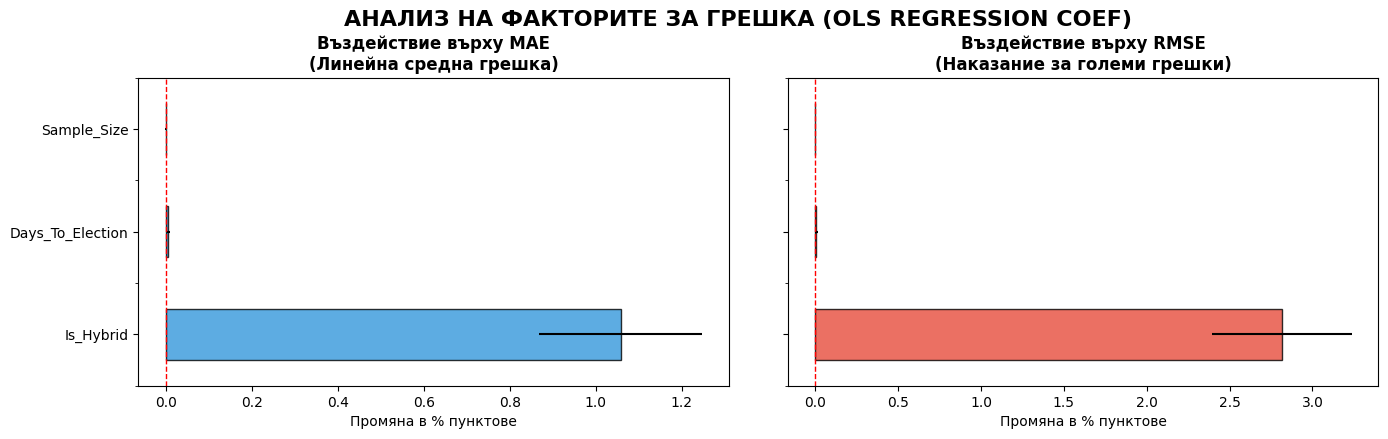

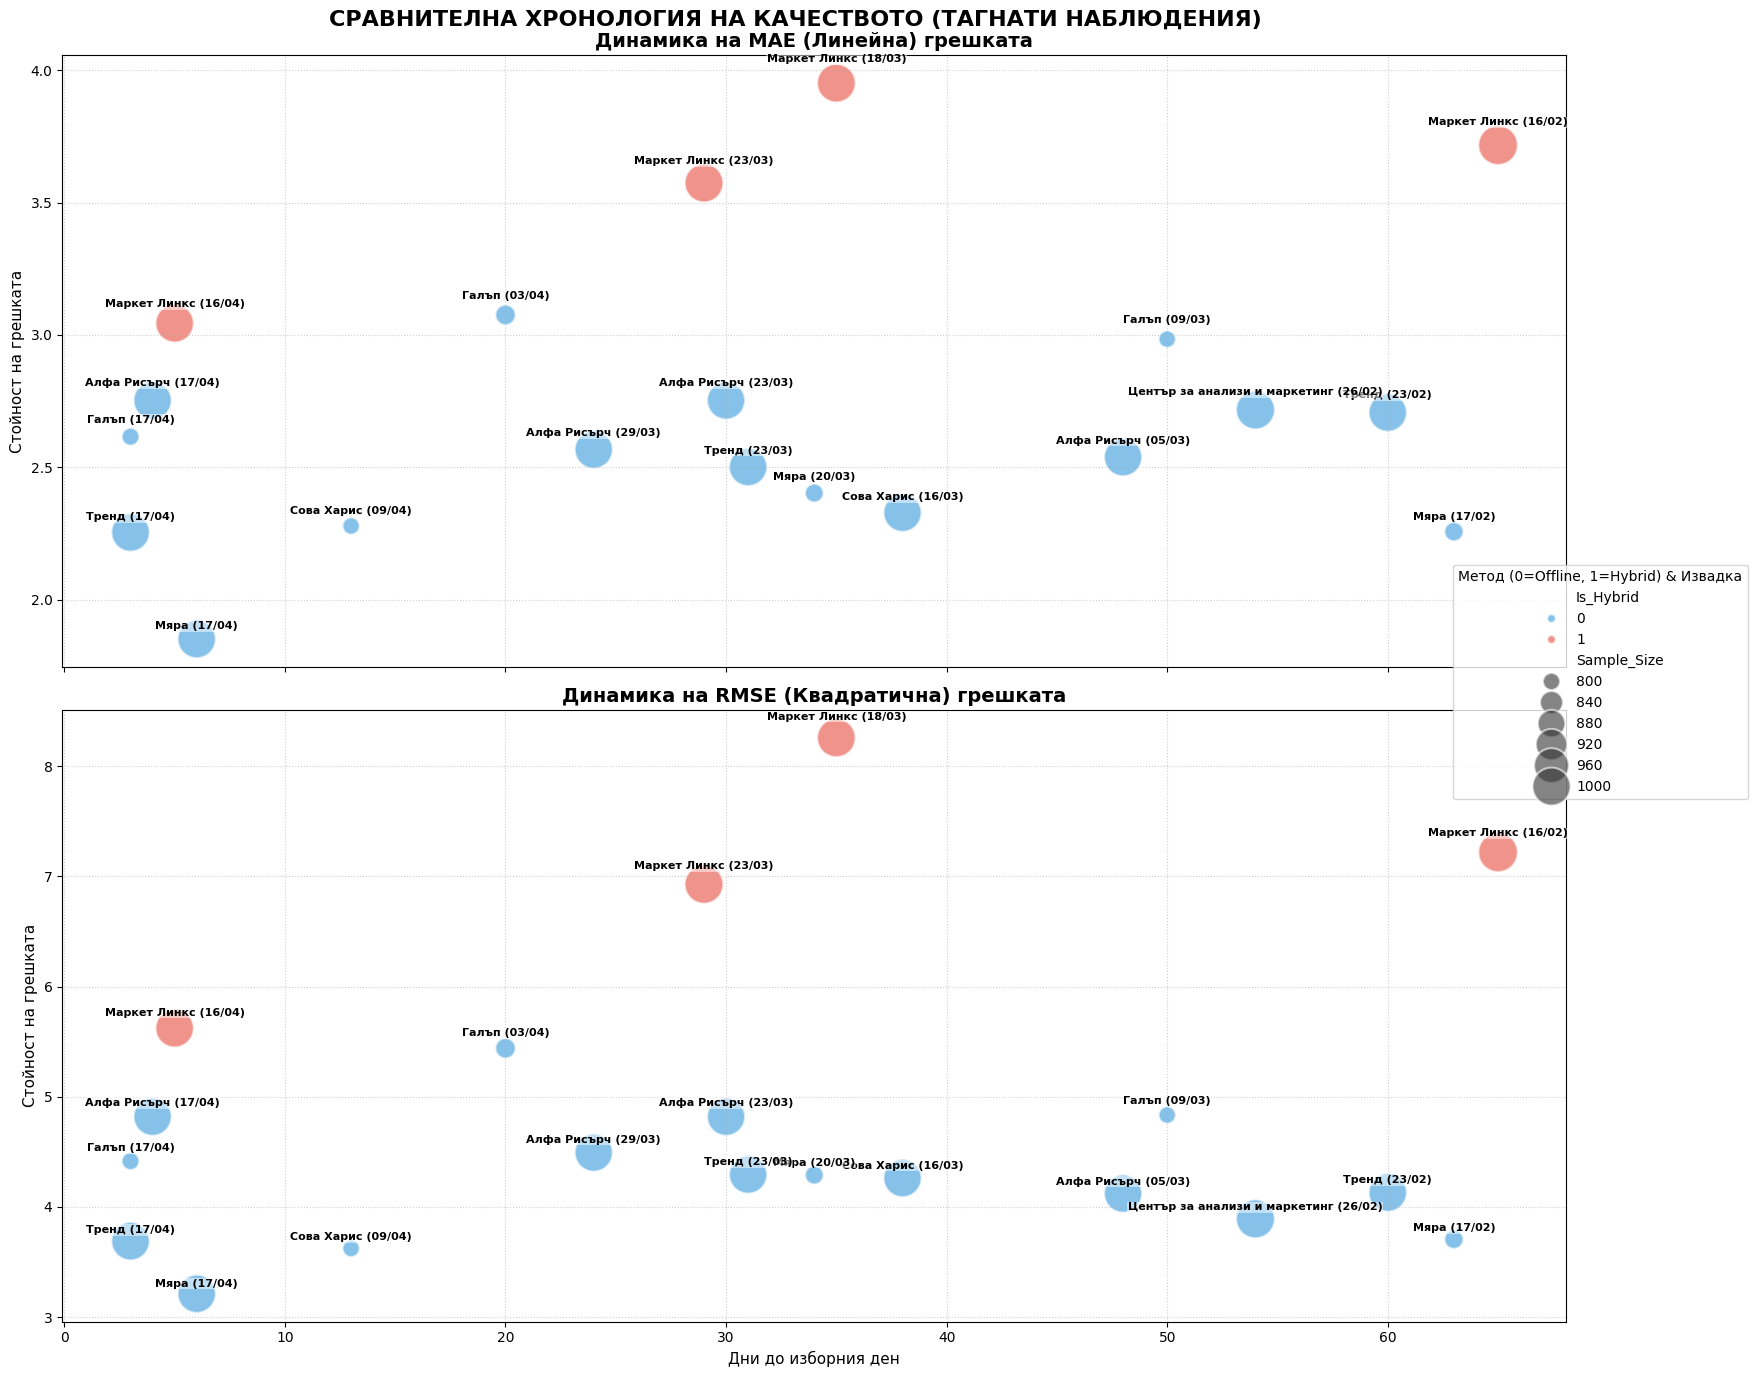


 СРАВНИТЕЛЕН АНАЛИЗ НА КОЕФИЦИЕНТИТЕ (MAE vs RMSE)
          Metric  MAE Coef  MAE P-value  RMSE Coef  RMSE P-value
       Is_Hybrid    1.0574       0.0000     2.8161        0.0000
Days_To_Election    0.0051       0.1617     0.0056        0.4806
     Sample_Size   -0.0005       0.5626    -0.0010        0.5954


In [30]:
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. ПРЕЦИЗНО ИЗЧИСЛЯВАНЕ НА МЕТРИКИТЕ ---
party_cols = [c for c in df.columns if c in actual.index]

def calculate_metrics(row):
    diffs = row[party_cols] - actual[party_cols]
    return pd.Series({
        'MAE': np.abs(diffs).mean(),
        'RMSE': np.sqrt((diffs**2).mean())
    })

metrics_df = df.apply(calculate_metrics, axis=1)

# --- 2. ПОДГОТОВКА НА ДАННИТЕ ЗА РЕГРЕСИЯ ---
election_date = pd.to_datetime('2026-04-19')
ols_data = []

for idx, row in df.iterrows():
    enc = row['metadata'].get('encoded', {})
    if not enc: continue

    ols_data.append({
        'Label': idx,
        'MAE': metrics_df.loc[idx, 'MAE'],
        'RMSE': metrics_df.loc[idx, 'RMSE'],
        'Is_Hybrid': 1 if enc.get('methodology') == 'hybrid' else 0,
        'Days_To_Election': (election_date - pd.to_datetime(enc.get('date'))).days,
        'Sample_Size': enc.get('sample_size', 0)
    })

reg_df = pd.DataFrame(ols_data).set_index('Label').dropna()

# --- 3. ИЗПЪЛНЕНИЕ НА РЕГРЕСИИТЕ ---
X = sm.add_constant(reg_df[['Is_Hybrid', 'Days_To_Election', 'Sample_Size']])
model_mae = sm.OLS(reg_df['MAE'], X).fit()
model_rmse = sm.OLS(reg_df['RMSE'], X).fit()

# --- 4. ВИЗУАЛИЗАЦИЯ 1: ВЛИЯНИЕ НА ФАКТОРИТЕ (КОЕФИЦИЕНТИ) ---
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4), sharey=True)
plt.subplots_adjust(wspace=0.1)

# MAE Coefs
model_mae.params[1:].plot(kind='barh', xerr=model_mae.bse[1:], color='#3498db', ax=ax1, alpha=0.8, edgecolor='black')
ax1.axvline(0, color='red', linestyle='--', linewidth=1)
ax1.set_title('Въздействие върху MAE\n(Линейна средна грешка)', fontweight='bold')
ax1.set_xlabel('Промяна в % пунктове')

# RMSE Coefs
model_rmse.params[1:].plot(kind='barh', xerr=model_rmse.bse[1:], color='#e74c3c', ax=ax2, alpha=0.8, edgecolor='black')
ax2.axvline(0, color='red', linestyle='--', linewidth=1)
ax2.set_title('Въздействие върху RMSE\n(Наказание за големи грешки)', fontweight='bold')
ax2.set_xlabel('Промяна в % пунктове')

plt.suptitle('АНАЛИЗ НА ФАКТОРИТЕ ЗА ГРЕШКА (OLS REGRESSION COEF)', fontsize=16, fontweight='bold', y=1.05)
plt.show()

# --- 5. ВИЗУАЛИЗАЦИЯ 2: SIDE-BY-SIDE ТАГНАТА ДИНАМИКА (MAE vs RMSE) ---
fig2, (ax3, ax4) = plt.subplots(2, 1, figsize=(16, 14), sharex=True)
palette = ['#3498db', '#e74c3c']

for ax, metric, color, title in zip([ax3, ax4], ['MAE', 'RMSE'], palette, ['MAE (Линейна)', 'RMSE (Квадратична)']):
    # Scatter plot
    sns.scatterplot(
        data=reg_df, x='Days_To_Election', y=metric,
        hue='Is_Hybrid', size='Sample_Size', sizes=(150, 800),
        palette=palette, alpha=0.6, edgecolor='white', linewidth=1.5, ax=ax
    )

    # Тагване на всяка точка
    for label, row in reg_df.iterrows():
        ax.text(
            x=row['Days_To_Election'],
            y=row[metric] + (row[metric] * 0.02), # динамично отместване нагоре
            s=label, fontsize=8, fontweight='semibold', ha='center',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=0.5)
        )

    ax.invert_xaxis()
    ax.set_title(f'Динамика на {title} грешката', fontsize=14, fontweight='bold')
    ax.set_xlabel('Дни до изборния ден', fontsize=11)
    ax.set_ylabel('Стойност на грешката', fontsize=11)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.get_legend().remove() # премахваме индивидуалните легенди за по-чист вид

# Единна легенда за целия плот
handles, labels = ax4.get_legend_handles_labels()
fig2.legend(handles, labels, title='Метод (0=Offline, 1=Hybrid) & Извадка', loc='center right', bbox_to_anchor=(1.1, 0.5))

plt.suptitle('СРАВНИТЕЛНА ХРОНОЛОГИЯ НА КАЧЕСТВОТО (ТАГНАТИ НАБЛЮДЕНИЯ)', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# --- 6. СТРУКТУРИРАН ТЕКСТОВ АУТПУТ ---
print("\n" + "="*60)
print(" СРАВНИТЕЛЕН АНАЛИЗ НА КОЕФИЦИЕНТИТЕ (MAE vs RMSE)")
print("="*60)
summary_table = pd.DataFrame({
    'Metric': ['Is_Hybrid', 'Days_To_Election', 'Sample_Size'],
    'MAE Coef': model_mae.params[1:].values,
    'MAE P-value': model_mae.pvalues[1:].values,
    'RMSE Coef': model_rmse.params[1:].values,
    'RMSE P-value': model_rmse.pvalues[1:].values
}).round(4)
print(summary_table.to_string(index=False))
print("="*60)

### Заключение и изводи от анализа

* **Системен пропуск:**
    * Всички агенции подцениха победителя (**Прогресивна България**) с над 10% средно отклонение.
    * Всички агенции надцениха установените играчи (**ГЕРБ, ДПС, Възраждане**) в различна степен.

* **Методология:**
    * Необходима е ревизия на моделите за разпределение на гласовете на нерешилите избиратели.
    * Необходима е критична ревизия на източниците и структурирането на извадката.

* **Информационна хигиена:**
    * Ефирът е пълен с демографски, психографски и поведенчески разпределения на вота, към които трябва да се подходи със скептицизъм, имайки предвид мащаба на анализираните отклонения.
    * Анализи на по-малки кохорти (напр. от типа "коя партия е донор на гласоподаватели") носят риск да са значително по-неточни.

* **Забележка:**
    * Нормализирането на толкова голям набор от изследвания изисква задълбочена работа.
    * Този анализ е по-скоро отправна точка за по-задълбочени бъдещи мета-анализи, целящи по добро измерване на електоралните нагласи.
    * Най-належащата задача би била ръчното преглеждане (QA) и коригиране на входящите данни.

In [10]:
# '%pip install qrcode[pil] -q'

# import qrcode
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# import pandas as pd
# import statsmodels.api as sm
# from matplotlib.backends.backend_pdf import PdfPages
# from google.colab import files

# # --- 1. КОНФИГУРАЦИЯ ---
# pdf_filename = "Election_Analysis_2026_Final_Report.pdf"
# gist_url = "https://gist.githubusercontent.com/gregordimi/e0d3fe30e4f898c84ad25c38b39f6e44/raw/311a84fb7ce48c8bc47d61b359405d602b2aabd6/results2026.json"
# notebook_url = "https://colab.research.google.com/drive/1Zu_q3iuHCEs0OmtctdoCo3ef7LvgTeru?usp=sharing"
# author_url = "https://linkedin.com/in/grigordimitrov"
# election_date = pd.to_datetime('2026-04-19')
# PAGE_SIZE = (11, 8.5)

# def get_qr_image(url):
#     qr = qrcode.QRCode(box_size=10, border=2)
#     qr.add_data(url)
#     qr.make(fit=True)
#     return qr.make_image(fill_color="black", back_color="white")

# def add_footer(fig, page_num, total_pages):
#     footer_text = f"Източник: Публични данни - Сайтове на агенции / Медии | Стр. {page_num} от {total_pages} | Забележка: Данните са събирани чрез бот, възможни са неточности"
#     fig.text(0.5, 0.04, footer_text, ha='center', fontsize=8, color='grey', alpha=0.7)

# # --- 2. ПОДГОТОВКА НА ДАННИ ---
# party_cols = [c for c in df.columns if c in actual.index]
# cols = [c for c in df.columns if c not in ['Agency', 'Date', 'metadata', 'Не съм решил']]

# def calculate_metrics(row):
#     diffs = row[party_cols] - actual[party_cols]
#     return pd.Series({'MAE': np.abs(diffs).mean(), 'RMSE': np.sqrt((diffs**2).mean())})

# metrics_all_df = df.apply(calculate_metrics, axis=1)

# ols_list = []
# for idx, row in df.iterrows():
#     enc = row['metadata'].get('encoded', {})
#     if not enc: continue
#     ols_list.append({
#         'Label': idx,
#         'MAE': metrics_all_df.loc[idx, 'MAE'],
#         'RMSE': metrics_all_df.loc[idx, 'RMSE'],
#         'Is_Hybrid': 1 if enc.get('methodology') == 'hybrid' else 0,
#         'Days_To_Election': (election_date - pd.to_datetime(enc.get('date'))).days,
#         'Sample_Size': enc.get('sample_size', 0)
#     })
# reg_df = pd.DataFrame(ols_list).dropna()

# X_reg = sm.add_constant(reg_df[['Is_Hybrid', 'Days_To_Election', 'Sample_Size']])
# model_mae = sm.OLS(reg_df['MAE'], X_reg).fit()
# model_rmse = sm.OLS(reg_df['RMSE'], X_reg).fit()

# target_parties = ['Прогресивна България', 'ГЕРБ', 'ПП-ДБ', 'ДПС', 'Възраждане']
# sorted_parties = actual[cols].sort_values(ascending=False).index
# total_p = 7 + len(target_parties)

# with PdfPages(pdf_filename) as pdf:

# # --- СТРАНИЦА 1: ЗАГЛАВИЕ (ADJUSTED) ---
#     fig = plt.figure(figsize=PAGE_SIZE)
#     plt.axis('off')

#     # DRAFT воден знак
#     plt.text(0.5, 0.96, 'DRAFT V2', ha='center', va='center', fontsize=40, fontweight='bold', color='red', alpha=0.7)

#     # Заглавие и Подзаглавие
#     plt.text(0.5, 0.88, 'Анализ на социологическата точност: Избори 2026', ha='center', fontsize=24, fontweight='bold', color='#003366')
#     plt.text(0.5, 0.80, 'Статистически анализ на факторите, влияещи върху грешката', ha='center', fontsize=14, style='italic', color='#444')

#     # Секция АВТОР И ЛИНКОВЕ
#     # Използваме url= параметър за кликаемост в PDF
#     plt.text(0.1, 0.70, f'Автор: Г. Д.', fontsize=12, fontweight='bold', color='#003366')
#     plt.text(0.1, 0.67, 'LinkedIn Профил', fontsize=11, color='blue', url=author_url, bbox=dict(facecolor='none', edgecolor='none', pad=0))

#     plt.text(0.1, 0.63, 'Източник на данни', fontsize=11, color='blue', url=gist_url)
#     plt.text(0.1, 0.59, 'Код на анализа', fontsize=11, color='blue', url=notebook_url)

#     plt.text(0.1, 0.54, f'Дата на анализ: {pd.Timestamp.now().strftime("%d.%m.%Y")}', fontsize=10, color='#666')

#     # Блок с метрики
#     metrics_note = ("• MAE (Средна абсолютна грешка): Линейно отклонение на прогнозата.\n"
#                     "• RMSE (Средноквадратична грешка): Подчертава големите индивидуални пропуски.\n"
#                     "• OLS Regression: Идентифицира кои фактори (метод, време, извадка) са статистически значими.")
#     plt.text(0.1, 0.40, metrics_note, fontsize=10, bbox=dict(facecolor='#f0f0f0', alpha=0.5, edgecolor='none', pad=5))

#     # QR Кодове (Запазваме ги като визуален елемент)
#     ax_qr0 = fig.add_axes([0.20, 0.12, 0.15, 0.15]); ax_qr0.imshow(get_qr_image(author_url), cmap='gray'); ax_qr0.axis('off'); ax_qr0.set_title("Автор", fontsize=8)
#     ax_qr1 = fig.add_axes([0.42, 0.12, 0.15, 0.15]); ax_qr1.imshow(get_qr_image(notebook_url), cmap='gray'); ax_qr1.axis('off'); ax_qr1.set_title("Код", fontsize=8)
#     ax_qr2 = fig.add_axes([0.64, 0.12, 0.15, 0.15]); ax_qr2.imshow(get_qr_image(gist_url), cmap='gray'); ax_qr2.axis('off'); ax_qr2.set_title("Данни", fontsize=8)

#     add_footer(fig, 1, total_p)
#     pdf.savefig(fig, dpi=300, bbox_inches='tight'); plt.close()

#     # --- СТРАНИЦА 6: МАТРИЦА НА ДАННИ ---
#     fig = plt.figure(figsize=PAGE_SIZE)
#     sns.heatmap(df[sorted_parties], annot=True, fmt='.1f', cmap='YlGnBu', annot_kws={"size": 8}, cbar_kws={'shrink': 0.8})
#     plt.title('Матрица на данните: Всички прогнози (%)', fontsize=16, fontweight='bold')
#     plt.xticks(rotation=45, ha='right', fontsize=9); plt.yticks(fontsize=8)
#     plt.tight_layout(rect=[0.05, 0.08, 0.95, 0.95])
#     add_footer(fig, 6, total_p)
#     pdf.savefig(fig, dpi=300); plt.close()

#     # --- СТРАНИЦА 2: RMSE СРЕЩУ MAE ---
#     metrics_summary = metrics_all_df.sort_values('RMSE')
#     fig, ax = plt.subplots(figsize=PAGE_SIZE)
#     y_indices = np.arange(len(metrics_summary))
#     ax.barh(y_indices - 0.17, metrics_summary['MAE'], 0.35, label='MAE', color='#3498db', alpha=0.8, edgecolor='black')
#     ax.barh(y_indices + 0.17, metrics_summary['RMSE'], 0.35, label='RMSE', color='#e74c3c', alpha=0.8, edgecolor='black')
#     ax.set_yticks(y_indices); ax.set_yticklabels(metrics_summary.index); ax.invert_yaxis()
#     ax.set_title('Сравнение на точността по агенции\n', fontsize=16, fontweight='bold')
#     ax.text(0.5, 1.02, 'Агрегирани стойности на MAE и RMSE спрямо официалния резултат', transform=ax.transAxes, ha='center', fontsize=11, color='#555')
#     ax.legend(); ax.grid(axis='x', linestyle='--', alpha=0.3)
#     plt.tight_layout(rect=[0.05, 0.08, 0.95, 0.92])
#     add_footer(fig, 2, total_p)
#     pdf.savefig(fig, dpi=300); plt.close()

#     # --- СТРАНИЦА 3: OLS КОЕФИЦИЕНТИ (С ТИТЛИ И ПОДЗАГЛАВИЯ) ---
#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=PAGE_SIZE, sharey=True)

#     model_mae.params[1:].plot(kind='barh', xerr=model_mae.bse[1:], color='#3498db', ax=ax1, alpha=0.8, edgecolor='black')
#     ax1.axvline(0, color='red', linestyle='--', linewidth=1)
#     ax1.set_title('Въздействие върху MAE\n', fontsize=13, fontweight='bold')
#     ax1.text(0.5, 1.02, 'Как факторите променят линейната грешка (%)', transform=ax1.transAxes, ha='center', fontsize=9, color='#555')

#     model_rmse.params[1:].plot(kind='barh', xerr=model_rmse.bse[1:], color='#e74c3c', ax=ax2, alpha=0.8, edgecolor='black')
#     ax2.axvline(0, color='red', linestyle='--', linewidth=1)
#     ax2.set_title('Въздействие върху RMSE\n', fontsize=13, fontweight='bold')
#     ax2.text(0.5, 1.02, 'Тежест на факторите при големи отклонения', transform=ax2.transAxes, ha='center', fontsize=9, color='#555')

#     plt.suptitle('СТАТИСТИЧЕСКА ЗНАЧИМОСТ НА ФАКТОРИТЕ (OLS)', fontsize=16, fontweight='bold', y=0.96)
#     # Свиване на графиките надолу чрез rect [left, bottom, right, top]
#     plt.tight_layout(rect=[0.05, 0.12, 0.95, 0.88])
#     add_footer(fig, 3, total_p)
#     pdf.savefig(fig, dpi=300); plt.close()

#     # --- СТРАНИЦА 4: SIDE-BY-SIDE ДИНАМИКА (С ТИТЛИ И ПОДЗАГЛАВИЯ) ---
#     fig, (ax3, ax4) = plt.subplots(1, 2, figsize=PAGE_SIZE)
#     titles = ['MAE Dynamics', 'RMSE Dynamics']
#     subtitles = ['Линейно отклонение във времето', 'Квадратично наказание за големи грешки']

#     for ax, metric, color, title, sub in zip([ax3, ax4], ['MAE', 'RMSE'], ['#3498db', '#e74c3c'], titles, subtitles):
#         sns.scatterplot(data=reg_df, x='Days_To_Election', y=metric, hue='Is_Hybrid', size='Sample_Size',
#                         sizes=(100, 700), palette={0: '#3498db', 1: '#e74c3c'}, alpha=0.6, edgecolor='black', ax=ax)
#         for _, row in reg_df.iterrows():
#             ax.text(row['Days_To_Election'], row[metric], s=row['Label'], fontsize=7, rotation=45, ha='left', va='bottom')

#         ax.invert_xaxis(); ax.grid(True, linestyle=':', alpha=0.6)
#         ax.set_title(f'{title}\n', fontsize=13, fontweight='bold')
#         ax.text(0.5, 1.02, sub, transform=ax.transAxes, ha='center', fontsize=9, color='#555')
#         ax.get_legend().remove()

#     handles, labels = ax4.get_legend_handles_labels()
#     fig.legend(handles, labels, title='Метод (0=F2F, 1=Hybrid)', loc='center right', bbox_to_anchor=(0.98, 0.5))
#     plt.suptitle('ХРОНОЛОГИЧНО РАЗПРЕДЕЛЕНИЕ НА ТОЧНОСТТА', fontsize=16, fontweight='bold', y=0.96)
#     # Свиване на графиките надолу
#     plt.tight_layout(rect=[0.05, 0.1, 0.88, 0.88])
#     add_footer(fig, 4, total_p)
#     pdf.savefig(fig, dpi=300); plt.close()

#     # --- СТРАНИЦА 5: МАТРИЦА НА ОТКЛОНЕНИЯТА ---
#     residuals = df[cols].sub(actual[cols], axis=1)
#     fig = plt.figure(figsize=PAGE_SIZE)
#     sns.heatmap(residuals[sorted_parties], annot=True, fmt='.1f', cmap='RdBu_r', center=0, annot_kws={"size": 8}, cbar_kws={'shrink': 0.8})
#     plt.title('Матрица на отклоненията (Прогноза - Реалност)', fontsize=16, fontweight='bold')
#     plt.xticks(rotation=45, ha='right', fontsize=9); plt.yticks(fontsize=8)
#     plt.tight_layout(rect=[0.05, 0.08, 0.95, 0.95])
#     add_footer(fig, 5, total_p)
#     pdf.savefig(fig, dpi=300); plt.close()



#     # --- СТРАНИЦИ 7-N: ТРЕНДОВЕ ---
#     curr_p = 7
#     trend_df = df.sort_values('Date')
#     for party in target_parties:
#         if party in trend_df.columns:
#             fig = plt.figure(figsize=PAGE_SIZE)
#             plt.plot(trend_df.index, trend_df[party], marker='o', color='#1f77b4', linewidth=2)
#             plt.axhline(y=actual[party], color='#d62728', linestyle='--', linewidth=3, label=f'Реалност ({actual[party]}%)')
#             plt.title(f'Тренд на прогнозите: {party}', fontsize=16, fontweight='bold')
#             plt.xticks(rotation=45, ha='right', fontsize=8); plt.legend(); plt.grid(alpha=0.3)
#             plt.tight_layout(rect=[0.05, 0.08, 0.95, 0.95])
#             add_footer(fig, curr_p, total_p)
#             pdf.savefig(fig, dpi=300); plt.close()
#             curr_p += 1

#     # --- ФИНАЛНА СТРАНИЦА: ЗАКЛЮЧЕНИЯ ---
#     fig = plt.figure(figsize=PAGE_SIZE)
#     plt.axis('off')
#     plt.text(0.05, 0.92, 'Заключение и изводи от анализа', fontsize=20, fontweight='bold', color='#003366')

#     y_pos = 0.82
#     conclusion_blocks = [
#         ("• Системен пропуск:", "Всички агенции подцениха победителя (Прогресивна България) с над 10% средно отклонение.", True),
#         ("", "Всички агенции надцениха установените играчи (ГЕРБ, ДПС, Възраждане) в различна степен.", True),
#         ("• Методология:", "Необходима е ревизия на моделите за разпределение на гласовете на нерешилите избиратели.", False),
#         ("", "Необходима е критична ревизия на източниците и структурирането на извадката.", True),
#         ("• Информационна хигиена:", "Ефирът е пълен с демографски, психографски и поведенчески разпределения на вота, към които", False),
#         ("", "трябва да се подходи със скептицизъм, имайки предвид мащаба на анализираните отклонения.", False),
#         ("", "Анализи на по-малки кохорти (напр. от типа коя партия е донор на гласоподаватели)", False),
#         ("", "носят риск да са значително по-неточни.", False),
#         ("• Забележка:", "Нормализирането на толкова голям набор от изследвания изисква задълбочена работа.", False),
#         ("", "Този анализ е по-скоро отправна точка за по-задълбочени бъдещи мета-анализи, целящи повишаване на прогнозната сила.", False),
#         ("", "Най-належащата задача би била ръчното преглеждане и коригиране на входящите данни.", False),
#     ]

#     for header, detail, add_space in conclusion_blocks:
#         if header: plt.text(0.05, y_pos, header, fontsize=13, fontweight='bold', color='#003366'); y_pos -= 0.05
#         plt.text(0.07, y_pos, detail, fontsize=12, color='#333333'); y_pos -= 0.05
#         if add_space: y_pos -= 0.02

#     rect = plt.Rectangle((0.03, 0.15), 0.94, 0.80, linewidth=1, edgecolor='#cccccc', facecolor='#f9f9f9', alpha=0.3, zorder=-1)
#     fig.patches.append(rect)
#     add_footer(fig, total_p, total_p)
#     pdf.savefig(fig, dpi=300, bbox_inches='tight'); plt.close()

# print(f"✅ Докладът е генериран успешно: {pdf_filename}")
# files.download(pdf_filename)